In [1]:
# from google.colab import drive
# import requests
# import numpy as np
# import seaborn as sn

# drive.mount('/content/gdrive/')

Data Loading

In [2]:
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt

DATA_DIR = r"D:\deap-dataset\data_preprocessed_python"

def load_subject(subject_num):
    """Loads s01.dat, s02.dat, etc."""
    file_path = os.path.join(DATA_DIR, f's{subject_num:02d}.dat')
    with open(file_path, 'rb') as f:
        raw_data = pickle.load(f, encoding='latin1')
    eeg = raw_data['data'][:, :32, :]
    labels = raw_data['labels']
    
    return eeg, labels

eeg_s01, labels_s01 = load_subject(1)
print(f"EEG Shape: {eeg_s01.shape} (Trials, Channels, Samples)")
print(f"Labels Shape: {labels_s01.shape} (Trials, Valence/Arousal/Dominance/Liking)")

EEG Shape: (40, 32, 8064) (Trials, Channels, Samples)
Labels Shape: (40, 4) (Trials, Valence/Arousal/Dominance/Liking)


# Unzip

In [3]:
cd /content/gdrive/Shareddrives/GCPDS/databases/DEAP/

[WinError 3] The system cannot find the path specified: '/content/gdrive/Shareddrives/GCPDS/databases/DEAP/'
d:\deap-dataset


d:\miniconda\envs\eeg_env\lib\site-packages\IPython\core\magics\osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [4]:
!unzip data_preprocessed_python

'unzip' is not recognized as an internal or external command,
operable program or batch file.


# load sub

The videos are in the order of Experiment_id, so not in the order of presentation. This means the first video is the same for each participant.

In [5]:
cd /content/gdrive/Shareddrives/GCPDS/databases/DEAP/

[WinError 3] The system cannot find the path specified: '/content/gdrive/Shareddrives/GCPDS/databases/DEAP/'
d:\deap-dataset


In [6]:
import pickle

In [7]:
i = 1
with open('data_preprocessed_python/s'+ '01' + '.dat', 'rb') as file:
  subject = pickle.load(file, encoding='latin1')

In [8]:
subject.keys()

dict_keys(['labels', 'data'])

In [9]:
subject['data'].shape

(40, 40, 8064)

In [10]:
subject['labels'].shape

(40, 4)

In [11]:
all_eeg = []
all_labels = []

for i in range(1, 33):
    eeg, labels = load_subject(i)
    all_eeg.append(eeg)
    all_labels.append(labels)
    if i % 8 == 0: print(f"Loaded {i}/32 subjects...")

X_all = np.array(all_eeg, dtype='float32') # Shape: (32, 40, 32, 8064)
y_all = np.array(all_labels, dtype='float32') # Shape: (32, 40, 4)

print(f"Total Data Shape: {X_all.shape} (Subjects, Trials, Channels, Samples)")

Loaded 8/32 subjects...
Loaded 16/32 subjects...
Loaded 24/32 subjects...
Loaded 32/32 subjects...
Total Data Shape: (32, 40, 32, 8064) (Subjects, Trials, Channels, Samples)


Create Model

In [23]:
import torch.nn as nn

class PearsonLSTM(nn.Module):
    def __init__(self, input_size=32, hidden_size=64, num_layers=2):
        super(PearsonLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return self.sigmoid(out)

model_jin = PearsonLSTM().cuda()
print(model_jin)

PearsonLSTM(
  (lstm): LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [24]:
class ZhaoCNN(nn.Module):
    def __init__(self):
        super(ZhaoCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=125)
        self.pool = nn.MaxPool1d(kernel_size=4)
        self.dropout = nn.Dropout(0.3) 
        self.fc1 = nn.Linear(64 * 1889, 128)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.sigmoid(self.fc2(x))
        return x

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
class PearsonLSTM(nn.Module):
    def __init__(self, input_size=32, hidden_size=64, num_layers=2):
        super(PearsonLSTM, self).__init__()
        # Adding dropout=0.3 to the LSTM layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=0.3)
        self.dropout = nn.Dropout(0.3) 
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :]) 
        out = self.fc(out)
        return self.sigmoid(out)

optimizer = torch.optim.Adam(model_jin.parameters(), lr=0.001, weight_decay=1e-4)

Training

In [26]:
import torch.optim as optim
import pandas as pd
import numpy as np

y_flat_bin = (y_all[:, :, 0] > 5).astype(float).reshape(-1)
X_flat = X_all.reshape(-1, 32, 8064)
groups = np.repeat(np.arange(32), 40)

final_results = []

model_jin = PearsonLSTM(input_size=32).cuda()
optimizer = optim.Adam(model_jin.parameters(), lr=0.001)
criterion = nn.BCELoss()
num_subjects = X_all.shape[0] 
groups = np.repeat(np.arange(num_subjects), 40)

for train_idx, test_idx in logo.split(X_flat, y_flat_bin, groups):
    subject_id = groups[test_idx][0] + 1
    y_train = torch.tensor(y_flat_bin[train_idx], dtype=torch.float32).unsqueeze(1).cuda()
    X_train_raw = X_flat[train_idx]
    X_train_pearson = torch.tensor(np.array([np.corrcoef(t) for t in X_train_raw]), dtype=torch.float32).cuda()
    model_jin.train()
    for epoch in range(20): 
        optimizer.zero_grad()
        outputs = model_jin(X_train_pearson)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
    
    model_jin.eval()
    with torch.no_grad():
        X_test_raw = X_flat[test_idx]
        y_test = torch.tensor(y_flat_bin[test_idx], dtype=torch.float32).unsqueeze(1).cuda()
        X_test_pearson = torch.tensor(np.array([np.corrcoef(t) for t in X_test_raw]), dtype=torch.float32).cuda()
        
        preds = (model_jin(X_test_pearson) > 0.5).float()
        acc = (preds == y_test).float().mean().item()
        
        print(f"Subject {subject_id}: Accuracy = {acc*100:.2f}%")
        final_results.append({'Subject': subject_id, 'Accuracy': acc})

avg_acc = np.mean([r['Accuracy'] for r in final_results])
print(f"\nSubject-Independent Mean Accuracy: {avg_acc*100:.2f}%")

Subject 1: Accuracy = 85.00%
Subject 2: Accuracy = 85.00%
Subject 3: Accuracy = 47.50%
Subject 4: Accuracy = 72.50%
Subject 5: Accuracy = 57.50%
Subject 6: Accuracy = 75.00%
Subject 7: Accuracy = 80.00%
Subject 8: Accuracy = 87.50%
Subject 9: Accuracy = 77.50%
Subject 10: Accuracy = 62.50%
Subject 11: Accuracy = 95.00%
Subject 12: Accuracy = 95.00%
Subject 13: Accuracy = 80.00%
Subject 14: Accuracy = 70.00%
Subject 15: Accuracy = 85.00%
Subject 16: Accuracy = 77.50%
Subject 17: Accuracy = 82.50%
Subject 18: Accuracy = 90.00%
Subject 19: Accuracy = 85.00%
Subject 20: Accuracy = 95.00%
Subject 21: Accuracy = 85.00%
Subject 22: Accuracy = 67.50%
Subject 23: Accuracy = 90.00%
Subject 24: Accuracy = 87.50%
Subject 25: Accuracy = 92.50%
Subject 26: Accuracy = 85.00%
Subject 27: Accuracy = 75.00%
Subject 28: Accuracy = 92.50%
Subject 29: Accuracy = 75.00%
Subject 30: Accuracy = 62.50%
Subject 31: Accuracy = 75.00%

Subject-Independent Mean Accuracy: 79.76%


In [27]:
from torch.utils.data import DataLoader, TensorDataset
cnn_results = []
for train_idx, test_idx in logo.split(X_cnn_input, y_flat_bin, groups):
    subject_id = groups[test_idx][0] + 1
    X_train_cpu = torch.tensor(X_cnn_input[train_idx], dtype=torch.float32)
    y_train_cpu = torch.tensor(y_flat_bin[train_idx], dtype=torch.float32).unsqueeze(1)
    train_loader = DataLoader(TensorDataset(X_train_cpu, y_train_cpu), batch_size=64, shuffle=True)
    model_zhao = ZhaoCNN().cuda()
    optimizer_zhao = optim.Adam(model_zhao.parameters(), lr=0.0005)
    criterion = nn.BCELoss()
    model_zhao.train()
    for epoch in range(15):
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.cuda(), batch_y.cuda()
            
            optimizer_zhao.zero_grad()
            outputs = model_zhao(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer_zhao.step()
            
    # 4. Evaluation Loop
    model_zhao.eval()
    with torch.no_grad():
        X_test = torch.tensor(X_cnn_input[test_idx], dtype=torch.float32).cuda()
        y_test = torch.tensor(y_flat_bin[test_idx], dtype=torch.float32).unsqueeze(1).cuda()
        preds = (model_zhao(X_test) > 0.5).float()
        acc = (preds == y_test).float().mean().item()
        
    print(f"Subject {subject_id} Accuracy: {acc*100:.2f}%")
    cnn_results.append({'Subject': subject_id, 'Accuracy': acc})

cnn_avg_acc = np.mean([r['Accuracy'] for r in cnn_results])
print(f"\nZhaoCNN Subject-Independent Mean Accuracy: {cnn_avg_acc*100:.2f}%")

Subject 1 Accuracy: 85.00%
Subject 2 Accuracy: 15.00%
Subject 3 Accuracy: 47.50%
Subject 4 Accuracy: 72.50%
Subject 5 Accuracy: 42.50%
Subject 6 Accuracy: 75.00%
Subject 7 Accuracy: 80.00%
Subject 8 Accuracy: 87.50%
Subject 9 Accuracy: 77.50%
Subject 10 Accuracy: 62.50%
Subject 11 Accuracy: 95.00%
Subject 12 Accuracy: 95.00%
Subject 13 Accuracy: 80.00%
Subject 14 Accuracy: 70.00%
Subject 15 Accuracy: 85.00%
Subject 16 Accuracy: 77.50%
Subject 17 Accuracy: 82.50%
Subject 18 Accuracy: 87.50%
Subject 19 Accuracy: 85.00%
Subject 20 Accuracy: 95.00%
Subject 21 Accuracy: 85.00%
Subject 22 Accuracy: 60.00%
Subject 23 Accuracy: 90.00%
Subject 24 Accuracy: 87.50%
Subject 25 Accuracy: 25.00%
Subject 26 Accuracy: 85.00%
Subject 27 Accuracy: 75.00%
Subject 28 Accuracy: 87.50%
Subject 29 Accuracy: 75.00%
Subject 30 Accuracy: 60.00%
Subject 31 Accuracy: 75.00%

ZhaoCNN Subject-Independent Mean Accuracy: 74.27%


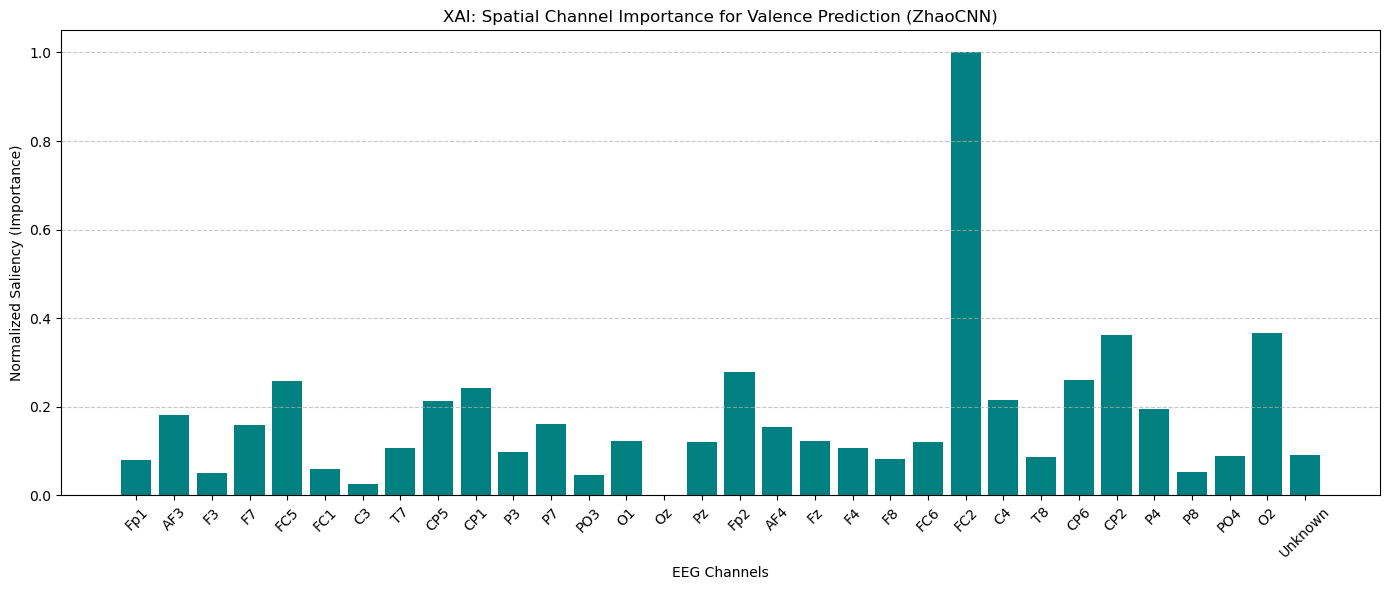

In [28]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def get_eeg_channel_importance(model, x):
    model.eval()
    x.requires_grad_()
    # Forward pass
    output = model(x)
    output.backward(torch.ones_like(output))
    gradients = x.grad.abs()
    channel_importance = gradients.mean(dim=(0, 2))
    channel_importance = (channel_importance - channel_importance.min()) / \
                         (channel_importance.max() - channel_importance.min())
    return channel_importance.cpu().detach().numpy()

X_test_xai = torch.tensor(X_cnn_input[test_idx], dtype=torch.float32).cuda()
original_activation = model_zhao.sigmoid
model_zhao.sigmoid = nn.Identity()


importances = get_eeg_channel_importance(model_zhao, X_test_xai)
model_zhao.sigmoid = original_activation

deap_channels = ['Fp1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7', 'CP5', 'CP1', 
                 'P3', 'P7', 'PO3', 'O1', 'Oz', 'Pz', 'Fp2', 'AF4', 'Fz', 'F4', 
                 'F8', 'FC6', 'FC2', 'C4', 'T8', 'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2', 'Unknown']

plt.figure(figsize=(14, 6))
plt.bar(deap_channels[:32], importances, color='teal')
plt.title("XAI: Spatial Channel Importance for Valence Prediction (ZhaoCNN)")
plt.ylabel("Normalized Saliency (Importance)")
plt.xlabel("EEG Channels")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [29]:
!pip install shap

SHAP

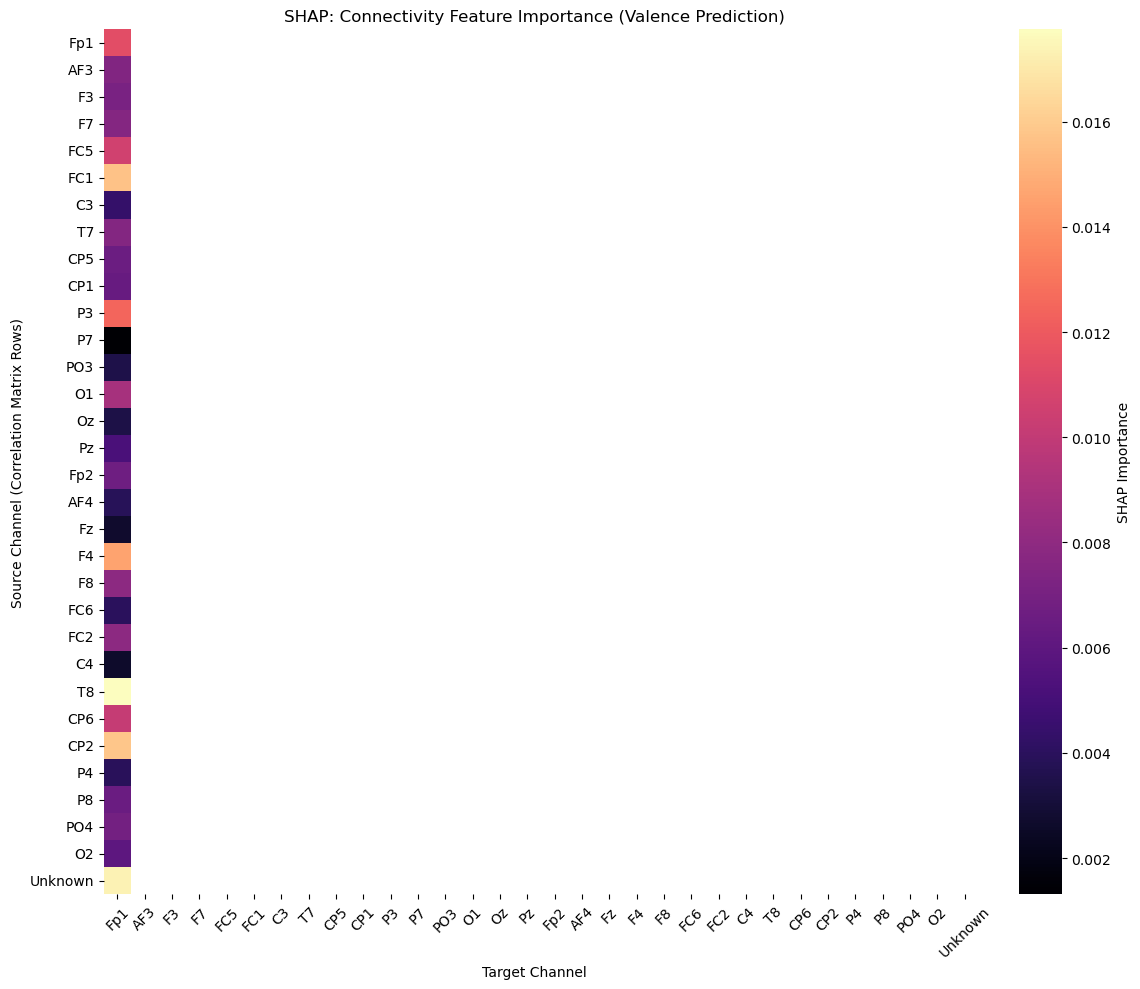

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(mean_shap, 
            xticklabels=deap_channels[:32], 
            yticklabels=deap_channels[:32], 
            cmap='magma', 
            cbar_kws={'label': 'SHAP Importance'})

plt.title("SHAP: Connectivity Feature Importance (Valence Prediction)")
plt.xlabel("Target Channel")
plt.ylabel("Source Channel (Correlation Matrix Rows)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

train_ds = TensorDataset(
    torch.tensor(X_lstm_input[train_idx], dtype=torch.float32), 
    torch.tensor(y_flat_bin[train_idx], dtype=torch.float32)
)

val_ds = TensorDataset(
    torch.tensor(X_lstm_input[test_idx], dtype=torch.float32), 
    torch.tensor(y_flat_bin[test_idx], dtype=torch.float32)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)


In [ ]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

num_epochs = 40 #

for epoch in range(num_epochs):
    model_jin.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.cuda(), batch_y.cuda()
        
        optimizer.zero_grad()
        outputs = model_jin(batch_X).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        preds = (outputs > 0.5).float()
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

    train_losses.append(running_loss / len(train_loader))
    train_accs.append(correct / total)

    model_jin.eval()
    v_loss_total, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.cuda(), batch_y.cuda()
            outputs = model_jin(batch_X).squeeze()
            
            v_loss = criterion(outputs, batch_y)
            v_loss_total += v_loss.item()
            preds = (outputs > 0.5).float()
            v_correct += (preds == batch_y).sum().item()
            v_total += batch_y.size(0)
            
    val_losses.append(v_loss_total / len(val_loader))
    val_accs.append(v_correct / v_total)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Acc: {train_accs[-1]:.2%} | Val Acc: {val_accs[-1]:.2%}")

Epoch [5/40] | Train Acc: 78.83% | Val Acc: 75.00%
Epoch [10/40] | Train Acc: 79.25% | Val Acc: 75.00%
Epoch [15/40] | Train Acc: 78.92% | Val Acc: 75.00%
Epoch [20/40] | Train Acc: 78.83% | Val Acc: 75.00%
Epoch [25/40] | Train Acc: 78.75% | Val Acc: 75.00%
Epoch [30/40] | Train Acc: 78.75% | Val Acc: 75.00%
Epoch [35/40] | Train Acc: 78.83% | Val Acc: 75.00%
Epoch [40/40] | Train Acc: 79.58% | Val Acc: 75.00%


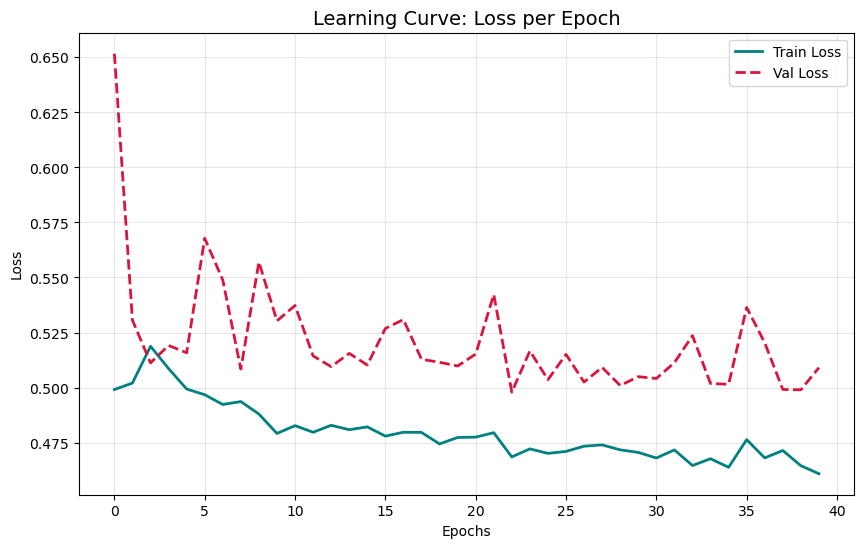

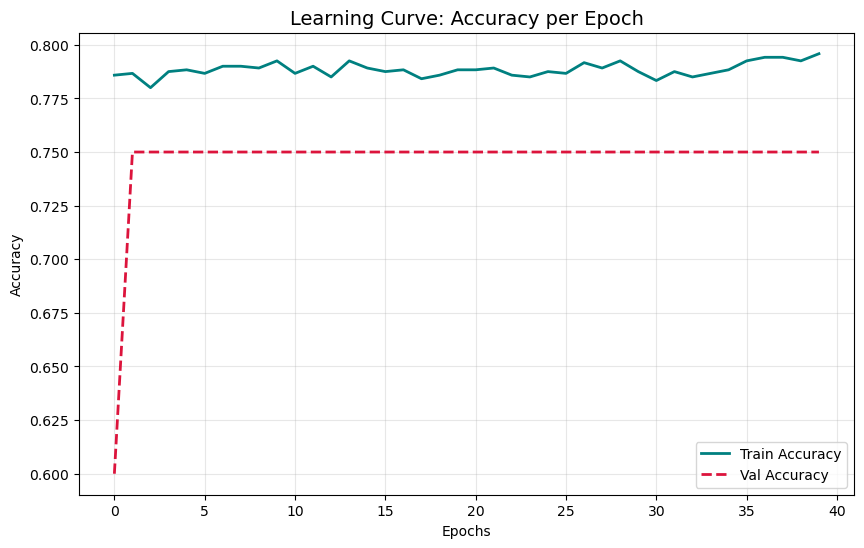

In [ ]:
plot_learning_curves(train_losses, val_losses, "Loss")
plot_learning_curves(train_accs, val_accs, "Accuracy")

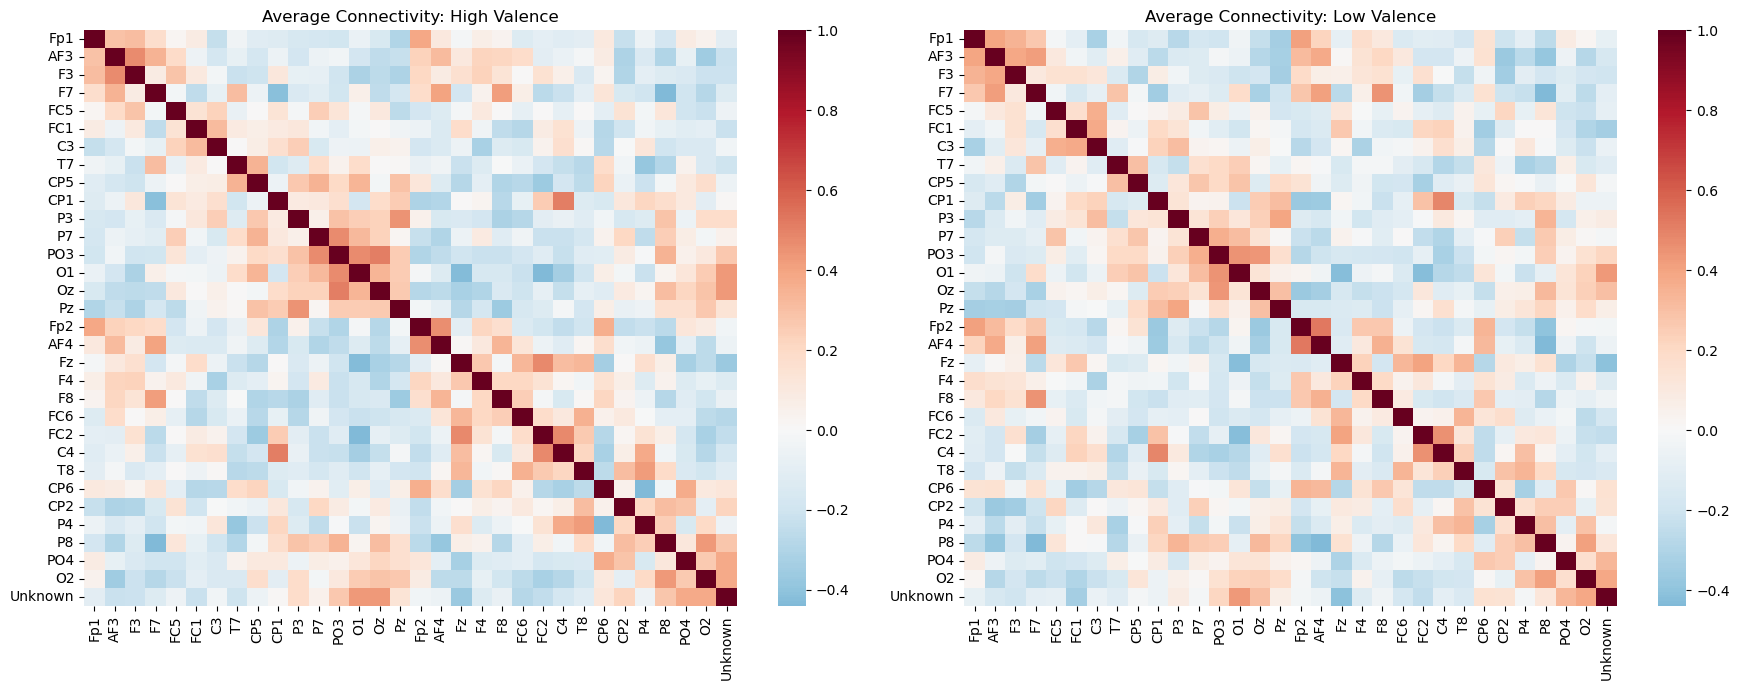

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

high_valence_idx = np.where(y_flat_bin == 1)[0]
low_valence_idx = np.where(y_flat_bin == 0)[0]
mean_high = np.mean(X_lstm_input[high_valence_idx], axis=0)
mean_low = np.mean(X_lstm_input[low_valence_idx], axis=0)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(mean_high, ax=axes[0], cmap='RdBu_r', center=0, 
            xticklabels=deap_channels[:32], yticklabels=deap_channels[:32])
axes[0].set_title("Average Connectivity: High Valence")

sns.heatmap(mean_low, ax=axes[1], cmap='RdBu_r', center=0, 
            xticklabels=deap_channels[:32], yticklabels=deap_channels[:32])
axes[1].set_title("Average Connectivity: Low Valence")

plt.tight_layout()
plt.show()